# Point Cloud Semantic Segmentation using Sparse Convolutions (MinkUNet)

**3D Data Processing 2025/2026**

Developed by: [Daniel Fusaro](https://bender97.github.io/) (fusarodani@dei.unipd.it)

## Course Project Assignment

In this assignment, you will implement the core components of a sparse 3D convolutional neural network, **MinkUNet**, from scratch using the **spconv** library. You will train it to perform point-level semantic segmentation on a reduced version of the **SemanticPOSS** dataset.

---

### Learning Objectives
1. Understand the mathematical and computational principles of **Sparse Tensors** and **Sparse Convolutions**.
2. Implement custom point-to-voxel quantization (voxelization) and sparse batching (collation).
3. Master the mapping of predictions from sparse voxel grids back to raw continuous point clouds using an **inverse coordinate mapping**.
4. Implement a custom **Sparse Gated Residual Block** and assemble a deep 3D sparse U-Net architecture.
5. Analyze the impact of key hyperparameters (voxel size, input features, data augmentation) on segmentation accuracy (mIoU), memory usage, and runtime.

---

## Background

### Why Sparse Convolutions?
Standard dense 3D convolutions are computationally and memory-wise prohibitive for large-scale outdoor point clouds. For instance, a typical LiDAR scan covering a $100m \times 100m \times 10m$ bounding box with a voxel resolution of $0.05m$ results in a dense grid of $2000 \times 2000 \times 200 = 8 \times 10^8$ voxels. Processing this densely requires gigabytes of memory per layer and spends massive computation on empty space.

Sparse convolutions solve this by storing and computing only on **active voxels** (voxels containing at least one point). In `spconv`, a sparse tensor is represented by:
- **Features ($F$)**: A PyTorch tensor of shape $[M, C_{in}]$ containing the features of the $M$ active voxels.
- **Indices ($I$)**: A PyTorch integer tensor of shape $[M, 4]$ storing coordinate indices in the format `[batch_index, x, y, z]`.
- **Spatial Shape**: A tuple representing the grid size along each dimension (e.g., `[grid_x, grid_y, grid_z]`).
- **Batch Size**: The number of samples in the current batch.

### Submanifold vs. Standard Sparse Convolutions
1. **Submanifold Convolution (`SubMConv3d`)**: Limits convolution outputs to the active input voxels. The output coordinates are identical to the input coordinates. This prevents "dilation" or "bloating" of the active voxels, maintaining high sparsity throughout the network.
2. **Sparse Convolution (`SparseConv3d`)**: Operates like standard convolutions. When using `stride > 1`, it downsamples the spatial grid, mapping the features to a coarser grid. This expands the active voxel locations locally.
3. **Inverse Sparse Convolution (`SparseInverseConv3d`)**: Restores the spatial coordinates of a previous downsampling stage. By specifying matching `indice_key` identifiers, `spconv` reuses the saved downsampling coordinate patterns to map features back to their original resolution without calculating new spatial coordinate relationships. This is crucial for U-Net skip connections.

---

### Didactic Guidelines & AI Honor Code
*Note: This notebook is specifically designed with custom gating modules and coordinate handling details. Standard AI code generation models (like GitHub Copilot or ChatGPT) are highly likely to produce syntax and runtime errors due to incorrect coordinate mapping or standard copy-paste template mismatch.*

**You are expected to code the logic yourself using the detailed API hints provided.**


## Google Colab Setup (Python 3.11 + CUDA 12.5)

This notebook is simplified for modern Google Colab runtimes.

Requirements already provided by Colab:
- Python 3.11
- CUDA 12.5
- PyTorch preinstalled

We only install a compatible sparse convolution backend (`spconv-cu121`).

### Notes for Students

- Use a **GPU runtime** in Colab (`Runtime -> Change runtime type -> GPU`).
- In the same runtime window, **choose an older version of the runtime** (`Runtime -> Change runtime type -> Runtime version -> 2025.07`).
  - This allows us to use Python 3.11
- Do **not** create virtual environments.
- Do **not** reinstall PyTorch or CUDA.
- The notebook now uses:
  - `spconv-cu121`
  - existing Colab PyTorch installation
- Restart runtime once after installation if imports fail the first time.

## Important!
SemanticPOSS Dataset folder is here: https://drive.google.com/drive/folders/1lW6VkCteqZFwfuBmO8x6YlRGpP42qOnH?usp=sharing

Open it in drive with the same Google Account folder you are using here in Colab (DO NOT USE THE @studenti.unipd.it account -> **google drive will not mount**. Use a personal @gmail.com account)

Add a shortcut to the shared SemanticPOSS folder
 - `right-click on SemanticPOSS folder -> Organize -> Add shortcut -> select "MyDrive" `

 In this way, you will find the dataset under `/content/drive/MyDrive/SemanticPOSS`

In [ ]:
!pip install spconv-cu121 ## be sure to have started the older runtime (2025.07)

⚠️⚠️ **Warning** ⚠️⚠️

Do not use your @studenti.unipd.it account.

Use a personal @gmail.com account.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

⚠️⚠️ **Warning** ⚠️⚠️

The next cell will fail while importing spconv.pytorch if you did not restart the session after spconv-cu121 installation.

It's vital that you do `Runtime -> Restart session` after any !pip install.



In [ ]:
import os

os.environ["SPCONV_DISABLE_JIT"] = "1"
os.environ["CUMM_DISABLE_JIT"] = "1"


import time
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import functools

try:
    import spconv.pytorch as spconv
    print("spconv.pytorch imported successfully!")
except ImportError:
    print("Warning: spconv is not installed. You will need to install it to run the model.")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

## 2. Dataset and Data Augmentation

We use a reduced version of the **SemanticPOSS** dataset, which follows the same layout as SemanticKITTI. Point clouds are stored in `.bin` files as flat `float32` arrays where each point is `[x, y, z, remission]`. Semantic labels are stored in `.label` files as flat `uint32` arrays, where the lower 16 bits contain the semantic class ID.

Below is the mapping from raw class IDs to our target 13 classes (IDs 0-12) and the ignore index `255` (for unlabeled points and dynamic objects).

In [ ]:
# Class mapping for SemanticPOSS
CLASS_MAPPING = {
    0: 255,   # unlabeled
    4: 0,     # person / people
    5: 0,     # person / people
    6: 1,     # rider
    7: 2,     # car
    8: 3,     # trunk (tree trunk)
    9: 4,     # plants / vegetation
    10: 5,    # traffic sign
    11: 5,    # traffic sign
    12: 5,    # traffic sign
    13: 6,    # pole
    14: 7,    # trashcan
    15: 8,    # building
    16: 9,    # cone / stone
    17: 10,   # fence
    21: 11,   # bike
    22: 12,   # ground
}

CLASS_NAMES = {
    0: "person",
    1: "rider",
    2: "car",
    3: "trunk",
    4: "plants",
    5: "traffic_sign",
    6: "pole",
    7: "trashcan",
    8: "building",
    9: "cone_stone",
    10: "fence",
    11: "bike",
    12: "ground"
}

def augment_point_cloud(coords, augment=True):
    """
    Apply basic data augmentations: rotation around Z, scaling, and jitter.
    """
    if not augment:
        return coords

    # 1. Random rotation around the vertical Z-axis
    theta = np.random.uniform(-np.pi, np.pi)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    rot_matrix = np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0],
        [0,      0,     1]
    ], dtype=np.float32)
    coords = np.dot(coords, rot_matrix)

    # 2. Random scaling
    scale = np.random.uniform(0.95, 1.05)
    coords = coords * scale

    # 3. Random Jitter (Gaussian noise)
    jitter = np.random.normal(0, 0.01, size=coords.shape).astype(np.float32)
    coords = coords + jitter

    return coords

class SemanticPOSSDataset(Dataset):
    def __init__(self, root_dir, sequences, augment=False):
        """
        Args:
            root_dir: Path to the dataset root folder (e.g. '/dataset')
            sequences: List of integers representing sequences to load (e.g. [0, 1, 2])
            augment: bool, whether to apply data augmentation
        """
        self.root_dir = root_dir
        self.sequences = sequences
        self.augment = augment
        self.file_list = []

        for seq in sequences:
            seq_str = f"{seq:02d}"
            velodyne_dir = os.path.join(root_dir, "sequences", seq_str, "velodyne")
            if not os.path.exists(velodyne_dir):
                continue
            files = sorted(os.listdir(velodyne_dir))
            for f in files:
                if f.endswith(".bin"):
                    name = f.split(".")[0]
                    self.file_list.append({
                        "velodyne": os.path.join(velodyne_dir, f),
                        "label": os.path.join(root_dir, "sequences", seq_str, "labels", name + ".label")
                    })

        print(f"Dataset initialized. Loaded {len(self.file_list)} point clouds from sequences {sequences}.")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_paths = self.file_list[idx]

        # Read flat binary point data (x, y, z, remission)
        points = np.fromfile(file_paths["velodyne"], dtype=np.float32).reshape(-1, 4)
        coords = points[:, :3]       # [N, 3]
        remission = points[:, 3:4]   # [N, 1]

        # Read binary label data (uint32)
        raw_labels = np.fromfile(file_paths["label"], dtype=np.uint32)
        sem_labels = raw_labels & 0xFFFF  # lower 16 bits contain semantic class ID

        # Map classes to target set
        mapped_labels = np.array([CLASS_MAPPING.get(l, 255) for l in sem_labels], dtype=np.int64)

        # Apply augmentation
        coords = augment_point_cloud(coords, augment=self.augment)

        # Prepend the original 3d coordinates to the features (very useful source of info!)
        concat_features = np.concatenate([coords, remission], axis=1)

        return {
            "coords": torch.from_numpy(coords).float(),
            "features": torch.from_numpy(concat_features).float(),
            "labels": torch.from_numpy(mapped_labels).long(),
        }

## 3. Voxelization and Collation (Student Task 1)

In sparse deep learning networks, data collation is more complex than simply stacking tensors because each point cloud has a different number of active voxels.

### Step-by-Step Voxelization and Collation Algorithm
For a batch of size $B$, you must iterate through each point cloud sample $i$:
1. **Coordinate Offsetting**: Shift the continuous 3D coordinates `coords` of the point cloud so that they are strictly non-negative. To do this, find the minimum coordinate across all 3 axes for that sample and subtract it from the coordinates. This ensures the voxel coordinates start at `0`.
2. **Coordinate Quantization**: Divide the shifted coordinates by the `voxel_size` and apply `floor` to obtain integer voxel grid coordinates: `discrete_coords = floor(shifted_coords / voxel_size)`.
3. **Grouping Unique Voxels**: Find the unique voxel coordinates. Since multiple points can fall into a single voxel, use `np.unique` with `axis=0` to identify unique rows. Retrieve both the **index of the first point in each voxel** (`unique_indices`) and the **inverse mapping** (`inverse_map`) that maps each original point to its unique voxel index:
   `unique_coords, unique_indices, inverse_map = np.unique(discrete_coords, axis=0, return_index=True, return_inverse=True)`
4. **Averaging Features**: Since multiple points share a voxel, compute the voxel feature as the **average** of the point features inside it.
   *Hint:* To do this efficiently, initialize a zero tensor of shape `[len(unique_coords), C]`, add all point features to their corresponding voxel indices using PyTorch's `index_add_` (https://docs.pytorch.org/docs/2.12/generated/torch.Tensor.index_add_.html), and divide by the number of points in each voxel.
5. **Selecting Voxel Labels**: For simplicity, assign the label of the **first point** that falls into the voxel (using `unique_indices`). Can you think of a more clever method?
6. **Prepending Batch Index**: In `spconv`, batching is achieved by setting the coordinate columns to `[batch_index, x, y, z]`. Prepend the batch index `i` (as an integer) to `unique_coords` to yield a tensor of shape `[M_i, 4]`.
7. **Accumulating the Global Inverse Map**: The evaluation must occur on the point level. To map the network's voxel predictions back to the original point indices, accumulate a batch-wide `inverse_map`. Note that the voxel index for sample `i` in the combined batch is shifted by the total number of voxels accumulated from all previous samples: `inverse_map_batch = inverse_map + voxel_offset`.
8. **Determining Spatial Shape**: To ensure that the downsampling layers (with total factor of $2^3 = 8$) align correctly in U-Net, the spatial shape must be divisible by 8. Find the maximum coordinate value along each axis ($x, y, z$) across the entire batch, round it up to the nearest multiple of 8, and return this as the `spatial_shape` parameter.

In [ ]:
def voxelize_and_collate_fn(batch, voxel_size):
    """
    Collate function to voxelize and batch point clouds for spconv.
    Fixes the point vanishing error by mapping all scans into a
    standardized fixed coordinate boundary box, ensuring perfect spatial alignment.
    """
    batch_coords = []
    batch_features = []
    batch_labels = []
    batch_point_labels = []
    batch_inverse_maps = []

    voxel_offset = 0

    # Define a standard fixed bounding range for SemanticPOSS point clouds.
    # This crops out extreme distant outliers and keeps the sensor center stabilized.
    MIN_BOUNDS = np.array([-50.0, -50.0, -4.0], dtype=np.float32)
    MAX_BOUNDS = np.array([50.0, 50.0, 6.0], dtype=np.float32)

    # 8. This task is already implemented for simplicity
    # 8. Compute the fixed grid shape dims based on our bounding box
    fixed_spatial_shape = np.floor((MAX_BOUNDS - MIN_BOUNDS) / voxel_size).astype(np.int32)
    # 8. Ensure spatial grid dimensions are cleanly divisible by 8 for U-Net down/up steps
    fixed_spatial_shape = [int(math.ceil(dim / 8.0) * 8) for dim in fixed_spatial_shape]

    for i, sample in enumerate(batch):
        coords = sample["coords"].numpy()       # [N, 3]
        features = sample["features"].numpy()   # [N, C]
        labels = sample["labels"].numpy()       # [N]

        # 1. Clip coordinates to the boundary frame to discard rogue outlier points
        coords = np.clip(coords, MIN_BOUNDS, MAX_BOUNDS)

        # 2. Coordinate Quantization relative to the fixed grid origin (non-negative)
        discrete_coords = np.floor((coords - MIN_BOUNDS) / voxel_size).astype(np.int32)

        # 3. Grouping Unique Voxels
        unique_coords, unique_indices, inverse_map = np.unique(discrete_coords, axis=0, return_index=True, return_inverse=True)

        # 4. Averaging Features inside each unique voxel using index_add_
        unique_coords_tensor = torch.from_numpy(unique_coords).int()
        features_tensor = torch.from_numpy(features).float()
        inverse_map_tensor = torch.from_numpy(inverse_map).long()

        num_voxels = len(unique_coords)
        voxel_feats_sum = torch.zeros(num_voxels, features_tensor.shape[1])
        voxel_counts = torch.zeros(num_voxels, 1)

        voxel_feats_sum.index_add_(0, inverse_map_tensor, features_tensor)
        voxel_counts.index_add_(0, inverse_map_tensor, torch.ones(len(features_tensor), 1))
        voxel_feats_avg = voxel_feats_sum / voxel_counts.clamp(min=1.0)

        # 5. Selecting Voxel Labels (using the first point's label)
        voxel_labels_sampled = torch.from_numpy(labels[unique_indices]).long()

        # 6. Prepending Batch Index Column [batch_idx, x, y, z]
        batch_idx_col = torch.full((num_voxels, 1), i, dtype=torch.int32)
        voxel_coords_batched = torch.cat([batch_idx_col, unique_coords_tensor], dim=1)

        # 7. Accumulating Global Inverse Map
        inverse_map_batch = inverse_map_tensor + voxel_offset
        voxel_offset += num_voxels

        batch_coords.append(voxel_coords_batched)
        batch_features.append(voxel_feats_avg)
        batch_labels.append(voxel_labels_sampled)
        batch_point_labels.append(torch.from_numpy(labels).long())
        batch_inverse_maps.append(inverse_map_batch)

    # Concatenate results from all samples in the batch
    voxel_coords = torch.cat(batch_coords, dim=0)
    voxel_features = torch.cat(batch_features, dim=0)
    voxel_labels = torch.cat(batch_labels, dim=0)
    point_labels = torch.cat(batch_point_labels, dim=0)
    inverse_map = torch.cat(batch_inverse_maps, dim=0)

    return {
        "voxel_coords": voxel_coords,
        "voxel_features": voxel_features,
        "voxel_labels": voxel_labels,
        "point_labels": point_labels,
        "inverse_map": inverse_map,
        "spatial_shape": fixed_spatial_shape,
        "batch_size": len(batch)
    }

In [ ]:
def test_collate_function():
    print("Running Collate Unit Test...")

    # Create mock batch of 2 samples
    sample1 = {
        "coords": torch.tensor([[0.1, 0.1, 0.1], [0.15, 0.1, 0.1], [1.2, 1.2, 1.2]], dtype=torch.float32),
        "features": torch.tensor([[1.0], [2.0], [3.0]], dtype=torch.float32),
        "labels": torch.tensor([0, 1, 2], dtype=torch.long)
    }
    sample2 = {
        "coords": torch.tensor([[0.5, 0.5, 0.5], [2.0, 2.0, 2.0]], dtype=torch.float32),
        "features": torch.tensor([[4.0], [5.0]], dtype=torch.float32),
        "labels": torch.tensor([3, 4], dtype=torch.long)
    }
    batch = [sample1, sample2]
    voxel_size = 0.2

    try:
        collate_output = voxelize_and_collate_fn(batch, voxel_size)
    except Exception as e:
        print(f"FAIL: collate function raised an exception: {e}")
        import traceback; traceback.print_exc()
        return

    required_keys = ["voxel_coords", "voxel_features", "voxel_labels", "point_labels", "inverse_map", "spatial_shape", "batch_size"]
    for key in required_keys:
        if key not in collate_output or collate_output[key] is None:
            print(f"FAIL: Missing key '{key}' or it is None.")
            return

    voxel_coords = collate_output["voxel_coords"]
    voxel_features = collate_output["voxel_features"]
    voxel_labels = collate_output["voxel_labels"]
    point_labels = collate_output["point_labels"]
    inverse_map = collate_output["inverse_map"]
    spatial_shape = collate_output["spatial_shape"]

    # Check shapes
    assert voxel_coords.dim() == 2 and voxel_coords.shape[1] == 4, f"voxel_coords shape must be [M_total, 4], got {voxel_coords.shape}"
    assert voxel_features.dim() == 2 and voxel_features.shape[1] == 1, f"voxel_features shape must be [M_total, 1], got {voxel_features.shape}"
    assert voxel_labels.dim() == 1, f"voxel_labels must be 1D, got {voxel_labels.shape}"
    assert point_labels.dim() == 1 and len(point_labels) == 5, f"point_labels length must be 5, got {len(point_labels)}"
    assert inverse_map.dim() == 1 and len(inverse_map) == 5, f"inverse_map length must be 5, got {len(inverse_map)}"

    # Sample 1:
    # [0.1, 0.1, 0.1] and [0.15, 0.1, 0.1] should fall into the same voxel [0, 0, 0] after floor((c - min_c)/voxel_size)
    # Average features should be (1.0 + 2.0)/2 = 1.5
    # Voxel label should be the first one = 0
    # Point [1.2, 1.2, 1.2] shifted: [1.1, 1.1, 1.1] -> grid coords [5, 5, 5] -> feature 3.0, label 2
    # So sample 1 has 2 unique voxels.

    # Sample 2:
    # [0.5, 0.5, 0.5] shifted: [0, 0, 0] -> grid [0, 0, 0] -> feature 4.0, label 3
    # [2.0, 2.0, 2.0] shifted: [1.5, 1.5, 1.5] -> grid [7, 7, 7] -> feature 5.0, label 4
    # So sample 2 has 2 unique voxels.
    # Total active active voxels in batch: 4

    assert len(voxel_features) == 4, f"Expected 4 unique voxels in batch, got {len(voxel_features)}"

    # Test feature averaging
    # First voxel of batch (sample 0, grid [0,0,0]) should have average feature 1.5
    feat_val = voxel_features[0].item()
    assert abs(feat_val - 1.5) < 1e-5 or abs(feat_val - 3.0) < 1e-5, f"Voxel features are not averaged correctly. Got {feat_val}"

    # Check that spatial shape is divisible by 8
    assert len(spatial_shape) == 3, f"spatial_shape must have 3 dimensions, got {len(spatial_shape)}"
    for dim in spatial_shape:
        assert dim % 8 == 0, f"Each dimension of spatial_shape must be divisible by 8, got {spatial_shape}"

    # Check coordinates are non-negative
    assert (voxel_coords[:, 1:] >= 0).all(), "Voxel spatial coordinates must be non-negative!"

    # Check inverse map correctness
    # Verify that point predictions mapped via inverse_map match voxel values
    mapped_feats = voxel_features[inverse_map]
    assert abs(mapped_feats[0].item() - 1.5) < 1e-5 or abs(mapped_feats[1].item() - 1.5) < 1e-5, "Inverse mapping is incorrect."

    print("PASS: Collate Unit Test passed successfully!")

test_collate_function()

## 4. Model Architecture (Student Tasks 2 & 3)

Now, you will implement the modules for the MinkUNet architecture.

### Task 2: Custom Sparse Gated Residual Block (`SparseGatedResBlock`)
To make the network robust, we implement a **voxel-wise gating mechanism** inside the residual block. Standard residual blocks add the convolution output directly to the shortcut: $x + f(x)$. A gated residual block computes a voxel-wise, channel-wise gating vector $g(x) \in [0, 1]^C$ from the block's input features using a lightweight MLP, and gates the convolution path:

$$\text{out} = \text{ReLU}(x + g(x) \odot \text{conv\_path}(x))$$

#### Layer Specifications
1. **Convolutional Path (`self.conv_path`)**: Use `spconv.SparseSequential` to chain:
   - `spconv.SubMConv3d` (in_channels, out_channels, kernel_size=3, padding=1, bias=False)
   - `nn.BatchNorm1d` (out_channels)
   - `nn.ReLU` (inplace=True)
   - `spconv.SubMConv3d` (out_channels, out_channels, kernel_size=3, padding=1, bias=False)
   - `nn.BatchNorm1d` (out_channels)
2. **Gating Path (`self.gating`)**: A voxel-wise Multi-Layer Perceptron using standard PyTorch `nn.Sequential` applied to `x.features`:
   - `nn.Linear` (in_channels, in_channels // 4)
   - `nn.ReLU` (inplace=True)
   - `nn.Linear` (in_channels // 4, in_channels)
   - `nn.Sigmoid` (outputs the gate vector between 0 and 1)

*Note on spconv features:* You must access the features of the sparse tensor using `x.features` (shape `[M, C]`) to feed them to the gating path. You must also multiply the convolution output features (`conv_out.features`) by the gating weights, add `x.features`, and wrap the resulting tensor using `x.replace_feature(new_features)` to preserve the coordinate tracking structure.

In [ ]:
class SparseBatchNorm1d(nn.BatchNorm1d):
    """
    A robust drop-in replacement for SparseBatchNorm1d that handles edge-case scenarios
    where spconv downsamples features to exactly 1 active voxel, avoiding the
    PyTorch ValueError during training.
    """
    def forward(self, input: torch.Tensor) -> torch.Tensor:
        # Check if we are running into the single active voxel scenario during training
        if self.training and input.shape[0] <= 1:
            # Bypass variance tracking calculations for this batch step
            if self.weight is not None:
                # Scale by trainable weight parameter if biases/weights exist
                if self.bias is not None:
                    return input * self.weight + self.bias
                return input * self.weight
            return input
        return super().forward(input)

In [ ]:
class SparseGatedResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # 1. Convolutional Path
        self.conv_path = spconv.SparseSequential(
            spconv.SubMConv3d(channels, channels, kernel_size=3, padding=1, bias=False),
            SparseBatchNorm1d(channels),
            nn.ReLU(inplace=True),
            spconv.SubMConv3d(channels, channels, kernel_size=3, padding=1, bias=False),
            SparseBatchNorm1d(channels)
        )

        # 2. Gating Path
        self.gating = nn.Sequential(
            nn.Linear(channels, channels // 4),
            nn.ReLU(inplace=True),
            nn.Linear(channels // 4, channels),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        conv_out = self.conv_path(x)
        gating_vector = self.gating(x.features)

        gated_conv_features = gating_vector * conv_out.features
        out_features = self.relu(x.features + gated_conv_features)

        return x.replace_feature(out_features)

In [ ]:
def test_sparse_gated_res_block():
    print("Running SparseGatedResBlock Unit Test...")
    if 'spconv' not in globals():
        print("SKIP: spconv is not installed.")
        return

    # Check if CUDA is available for spconv
    test_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if test_device.type == 'cpu':
        print("SKIP: spconv requires a CUDA device to run implicit GEMM convolutions.")
        return

    features = torch.randn(10, 16).to(test_device)
    indices = torch.tensor([[0, 0, 0, 0], [0, 1, 1, 1], [0, 2, 2, 2]] + [[0, i, i, i] for i in range(3, 10)], dtype=torch.int32).to(test_device)
    spatial_shape = [16, 16, 16]
    batch_size = 1

    try:
        x = spconv.SparseConvTensor(features, indices, spatial_shape, batch_size)
        block = SparseGatedResBlock(16).to(test_device)
        out = block(x)
    except Exception as e:
        print(f"FAIL: SparseGatedResBlock raised an exception: {e}")
        import traceback; traceback.print_exc()
        return

    assert isinstance(out, spconv.SparseConvTensor), f"Output must be a SparseConvTensor, got {type(out)}"
    assert out.features.shape == (10, 16), f"Output features shape must be [10, 16], got {out.features.shape}"
    assert (out.indices == x.indices).all(), "Indices (sparsity pattern) must not change in SubM convolution!"

    has_gating_layer = False
    for name, module in block.named_modules():
        if isinstance(module, nn.Sigmoid):
            has_gating_layer = True
            break
    assert has_gating_layer, "SparseGatedResBlock must contain a Sigmoid activation in its gating path."

    print("PASS: SparseGatedResBlock Unit Test passed successfully!")

test_sparse_gated_res_block()

### Task 3: MinkUNet Architecture

You will now assemble the `MinkUNet` model. A U-Net style sparse network downsamples features using sparse convolutions and upsamples using sparse inverse convolutions. Skip connections concatenate decoder and encoder features that share the same resolution.

#### Layer and Dimension Specifications
- **Input Layer**: `spconv.SparseSequential` that takes `in_channels` and maps them to **32 channels** using `SubMConv3d` (kernel size 3, padding 1, bias=False) followed by `nn.BatchNorm1d` and `nn.ReLU`.
- **Encoder Stage 1**:
  - Downsampling: `spconv.SparseSequential` containing `spconv.SparseConv3d` (32 -> 64 channels, kernel size 3, stride 2, padding 1, bias=False, `indice_key="down1"`), `BatchNorm1d(64)`, and `ReLU`.
  - Residual Block: `SparseGatedResBlock(64)`.
- **Encoder Stage 2**:
  - Downsampling: `spconv.SparseSequential` containing `spconv.SparseConv3d` (64 -> 128 channels, kernel size 3, stride 2, padding 1, bias=False, `indice_key="down2"`), `BatchNorm1d(128)`, and `ReLU`.
  - Residual Block: `SparseGatedResBlock(128)`.
- **Encoder Stage 3**:
  - Downsampling: `spconv.SparseSequential` containing `spconv.SparseConv3d` (128 -> 256 channels, kernel size 3, stride 2, padding 1, bias=False, `indice_key="down3"`), `BatchNorm1d(256)`, and `ReLU`.
  - Residual Block: `SparseGatedResBlock(256)`.
- **Decoder Stage 3**:
  - Upsampling: `spconv.SparseSequential` containing `spconv.SparseInverseConv3d` (256 -> 128 channels, kernel size 3, bias=False, `indice_key="down3"`), `BatchNorm1d(128)`, and `ReLU`.
  - Concatenation: Concatenate upsampled features with Encoder Stage 2 features (128 + 128 = 256 channels).
  - Fusion: `spconv.SparseSequential` containing `spconv.SubMConv3d` (256 -> 128 channels, kernel size 3, padding 1, bias=False), `BatchNorm1d(128)`, and `ReLU`.
- **Decoder Stage 2**:
  - Upsampling: `spconv.SparseSequential` containing `spconv.SparseInverseConv3d` (128 -> 64 channels, kernel size 3, bias=False, `indice_key="down2"`), `BatchNorm1d(64)`, and `ReLU`.
  - Concatenation: Concatenate upsampled features with Encoder Stage 1 features (64 + 64 = 128 channels).
  - Fusion: `spconv.SparseSequential` containing `spconv.SubMConv3d` (128 -> 64 channels, kernel size 3, padding 1, bias=False), `BatchNorm1d(64)`, and `ReLU`.
- **Decoder Stage 1**:
  - Upsampling: `spconv.SparseSequential` containing `spconv.SparseInverseConv3d` (64 -> 32 channels, kernel size 3, bias=False, `indice_key="down1"`), `BatchNorm1d(32)`, and `ReLU`.
  - Concatenation: Concatenate upsampled features with Input Layer features (32 + 32 = 64 channels).
  - Fusion: `spconv.SparseSequential` containing `spconv.SubMConv3d` (64 -> 32 channels, kernel size 3, padding 1, bias=False), `BatchNorm1d(32)`, and `ReLU`.
- **Classifier**: A linear classifier mapping from 32 channels to `num_classes` applied to the final voxel features.

#### Skip Connection Implementation Hint
In `forward()`, when concatenating features of two sparse tensors `up` (decoder) and `enc` (encoder), use `torch.cat([up.features, enc.features], dim=-1)`. Then, wrap it back into a sparse tensor with `up.replace_feature(cat_features)` before feeding it to the fusion sequential block.

In [ ]:
class MinkUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=13):
        super().__init__()

        # Input Layer
        self.input_layer = spconv.SparseSequential(
            spconv.SubMConv3d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            SparseBatchNorm1d(32),
            nn.ReLU(inplace=True)
        )

        # Encoder Stage 1
        self.enc1_down = spconv.SparseSequential(
            spconv.SparseConv3d(32, 64, kernel_size=3, stride=2, padding=1, bias=False, indice_key="down1"),
            SparseBatchNorm1d(64),
            nn.ReLU(inplace=True)
        )
        self.enc1_block = SparseGatedResBlock(64)

        # Encoder Stage 2
        self.enc2_down = spconv.SparseSequential(
            spconv.SparseConv3d(64, 128, kernel_size=3, stride=2, padding=1, bias=False, indice_key="down2"),
            SparseBatchNorm1d(128),
            nn.ReLU(inplace=True)
        )
        self.enc2_block = SparseGatedResBlock(128)

        # Encoder Stage 3
        self.enc3_down = spconv.SparseSequential(
            spconv.SparseConv3d(128, 256, kernel_size=3, stride=2, padding=1, bias=False, indice_key="down3"),
            SparseBatchNorm1d(256),
            nn.ReLU(inplace=True)
        )
        self.enc3_block = SparseGatedResBlock(256)

        # Decoder Stage 3
        self.dec3_up = spconv.SparseSequential(
            spconv.SparseInverseConv3d(256, 128, kernel_size=3, bias=False, indice_key="down3"),
            SparseBatchNorm1d(128),
            nn.ReLU(inplace=True)
        )
        self.dec3_fusion = spconv.SparseSequential(
            spconv.SubMConv3d(256, 128, kernel_size=3, padding=1, bias=False),
            SparseBatchNorm1d(128),
            nn.ReLU(inplace=True)
        )

        # Decoder Stage 2
        self.dec2_up = spconv.SparseSequential(
            spconv.SparseInverseConv3d(128, 64, kernel_size=3, bias=False, indice_key="down2"),
            SparseBatchNorm1d(64),
            nn.ReLU(inplace=True)
        )
        self.dec2_fusion = spconv.SparseSequential(
            spconv.SubMConv3d(128, 64, kernel_size=3, padding=1, bias=False),
            SparseBatchNorm1d(64),
            nn.ReLU(inplace=True)
        )

        # Decoder Stage 1
        self.dec1_up = spconv.SparseSequential(
            spconv.SparseInverseConv3d(64, 32, kernel_size=3, bias=False, indice_key="down1"),
            SparseBatchNorm1d(32),
            nn.ReLU(inplace=True)
        )
        self.dec1_fusion = spconv.SparseSequential(
            spconv.SubMConv3d(64, 32, kernel_size=3, padding=1, bias=False),
            SparseBatchNorm1d(32),
            nn.ReLU(inplace=True)
        )

        # Final Classifier
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # Input Layer
        x_in = self.input_layer(x)
        # Encoder path
        x_enc1 = self.enc1_down(x_in)
        x_enc1 = self.enc1_block(x_enc1)

        x_enc2 = self.enc2_down(x_enc1)
        x_enc2 = self.enc2_block(x_enc2)

        x_enc3 = self.enc3_down(x_enc2)
        x_enc3 = self.enc3_block(x_enc3)

        # Decoder path with skip connections
        x_dec3 = self.dec3_up(x_enc3)
        cat_feat3 = torch.cat([x_dec3.features, x_enc2.features], dim=-1)
        x_dec3 = x_dec3.replace_feature(cat_feat3)
        x_dec3 = self.dec3_fusion(x_dec3)

        x_dec2 = self.dec2_up(x_dec3)
        cat_feat2 = torch.cat([x_dec2.features, x_enc1.features], dim=-1)
        x_dec2 = x_dec2.replace_feature(cat_feat2)
        x_dec2 = self.dec2_fusion(x_dec2)

        x_dec1 = self.dec1_up(x_dec2)
        cat_feat1 = torch.cat([x_dec1.features, x_in.features], dim=-1)
        x_dec1 = x_dec1.replace_feature(cat_feat1)
        x_dec1 = self.dec1_fusion(x_dec1)

        # Classifier mapping
        logits = self.classifier(x_dec1.features)
        return logits

In [ ]:
def test_minkunet_model():
    print("Running MinkUNet Unit Test...")
    if 'spconv' not in globals():
        print("SKIP: spconv is not installed.")
        return

    # Check if a valid CUDA device is available
    test_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if test_device.type == 'cpu':
        print("SKIP: spconv requires a CUDA device to run implicit GEMM convolutions.")
        return

    # Send all inputs to the GPU device
    features = torch.randn(128, 1).to(test_device)
    coords = torch.randint(0, 32, (128, 3))
    batch_idx = torch.randint(0, 2, (128, 1))
    indices = torch.cat([batch_idx, coords], dim=1).int().to(test_device)

    spatial_shape = [32, 32, 32]
    batch_size = 2

    try:
        x = spconv.SparseConvTensor(features, indices, spatial_shape, batch_size)
        # Instantiate and push the network to the GPU
        model = MinkUNet(in_channels=1, num_classes=13).to(test_device)
        logits = model(x)
    except Exception as e:
        print(f"FAIL: MinkUNet forward pass raised an exception: {e}")
        import traceback; traceback.print_exc()
        return

    assert isinstance(logits, torch.Tensor), f"Output must be a torch.Tensor, got {type(logits)}"
    assert logits.shape == (128, 13), f"Output logits shape must be [128, 13], got {logits.shape}"

    print("PASS: MinkUNet Unit Test passed successfully!")

test_minkunet_model()

## 5. Training, Evaluation, and Utilities (Implemented)

We provide the training, validation, and evaluation infrastructure.
- `compute_iou` computes the class-wise and mean Intersection-over-Union (mIoU) on the point level, filtering out the ignore index `255`.
- `train_one_epoch` runs training on the voxel-level predictions.
- `evaluate` performs inference, uses the `inverse_map` to project voxel-level predictions back to the original point cloud size, and calculates mIoU on the points.

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# ============================================================
# IoU COMPUTATION
# ============================================================

def compute_iou(preds, targets, num_classes=13, ignore_label=255):
    """
    Computes per-class IoU and mean IoU.
    """
    if isinstance(preds, torch.Tensor):
        preds = preds.cpu().numpy()

    if isinstance(targets, torch.Tensor):
        targets = targets.cpu().numpy()

    mask = (targets != ignore_label)

    preds = preds[mask]
    targets = targets[mask]

    class_ious = []

    for c in range(num_classes):
        intersection = np.sum((preds == c) & (targets == c))
        union = np.sum((preds == c) | (targets == c))

        if union == 0:
            class_ious.append(np.nan)
        else:
            class_ious.append(intersection / union)

    return np.array(class_ious)


# ============================================================
# TRAINING LOOP
# ============================================================

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """
    Trains model for one epoch.
    Returns:
        avg_loss
    """
    model.train()

    running_loss = 0.0
    start_time = time.time()

    progress_bar = tqdm(
        enumerate(dataloader),
        total=len(dataloader),
        desc="Training",
        leave=False
    )

    for batch_idx, batch in progress_bar:

        voxel_coords = batch["voxel_coords"].to(device)
        voxel_features = batch["voxel_features"].to(device)
        voxel_labels = batch["voxel_labels"].to(device)

        spatial_shape = batch["spatial_shape"]
        batch_size = batch["batch_size"]

        x = spconv.SparseConvTensor(
            voxel_features,
            voxel_coords,
            spatial_shape,
            batch_size
        )

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, voxel_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        avg_loss = running_loss / (batch_idx + 1)

        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}"
        })

    epoch_time = time.time() - start_time
    avg_loss = running_loss / len(dataloader)

    print(f"Train Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s")

    return avg_loss


# ============================================================
# EVALUATION LOOP
# ============================================================

def evaluate(model,
             dataloader,
             criterion,
             device,
             split_name="Validation",
             num_classes=13,
             ignore_label=255):
    """
    Evaluates model.
    Returns:
        avg_loss
        mean_iou
        class_ious
    """

    model.eval()

    all_preds = []
    all_targets = []

    running_loss = 0.0

    start_time = time.time()

    progress_bar = tqdm(
        enumerate(dataloader),
        total=len(dataloader),
        desc=f"{split_name}",
        leave=False
    )

    with torch.no_grad():

        for batch_idx, batch in progress_bar:

            voxel_coords = batch["voxel_coords"].to(device)
            voxel_features = batch["voxel_features"].to(device)
            voxel_labels = batch["voxel_labels"].to(device)

            spatial_shape = batch["spatial_shape"]
            batch_size = batch["batch_size"]

            x = spconv.SparseConvTensor(
                voxel_features,
                voxel_coords,
                spatial_shape,
                batch_size
            )

            logits = model(x)

            # ------------------------
            # LOSS
            # ------------------------
            loss = criterion(logits, voxel_labels)
            running_loss += loss.item()

            # ------------------------
            # PREDICTIONS
            # ------------------------
            voxel_preds = torch.argmax(logits, dim=-1)

            inverse_map = batch["inverse_map"].to(device)

            point_preds = voxel_preds[inverse_map]
            point_labels = batch["point_labels"].to(device)

            all_preds.append(point_preds.cpu())
            all_targets.append(point_labels.cpu())

            avg_loss = running_loss / (batch_idx + 1)

            progress_bar.set_postfix({
                "loss": f"{avg_loss:.4f}"
            })

    # concatenate predictions
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    # compute IoU
    class_ious = compute_iou(
        all_preds,
        all_targets,
        num_classes=num_classes,
        ignore_label=ignore_label
    )

    mean_iou = np.nanmean(class_ious)

    avg_loss = running_loss / len(dataloader)

    elapsed = time.time() - start_time

    print(
        f"{split_name} Loss: {avg_loss:.4f} | "
        f"mIoU: {mean_iou*100:.2f}% | "
        f"Time: {elapsed:.2f}s"
    )

    return avg_loss, mean_iou, class_ious


# ============================================================
# MAIN TRAINING FUNCTION
# ============================================================

def run_training_experiment(
    voxel_size=0.1,
    use_remission=True,
    augment=True,
    num_epochs=5,
    batch_size=2
):

    print("=" * 70)
    print("STARTING TRAINING EXPERIMENT")
    print("=" * 70)

    print(f"Voxel Size     : {voxel_size}")
    print(f"Use Remission  : {use_remission}")
    print(f"Data Augment   : {augment}")
    print(f"Epochs         : {num_epochs}")
    print(f"Batch Size     : {batch_size}")
    print("=" * 70)

    # ========================================================
    # DATASETS
    # ========================================================

    print("\nLoading datasets...")

    # TRAIN = sequence 0
    train_dataset = SemanticPOSSDataset(
        root_dir='/content/drive/MyDrive/SemanticPOSS',
        sequences=[0],
        augment=augment
    )

    # VALIDATION = sequence 1
    val_dataset = SemanticPOSSDataset(
        root_dir='/content/drive/MyDrive/SemanticPOSS',
        sequences=[1],
        augment=False
    )

    print(f"Train samples : {len(train_dataset)}")
    print(f"Val samples   : {len(val_dataset)}")

    # ========================================================
    # COLLATE FUNCTION
    # ========================================================

    def custom_collate(batch):
        if not use_remission:
            for sample in batch:
                sample["features"][:, -1] = torch.ones_like(sample["features"][:, -1])
        voxel_size_xyz = [voxel_size, voxel_size, voxel_size]

        return voxelize_and_collate_fn(batch, voxel_size_xyz)

    # ========================================================
    # DATALOADERS
    # ========================================================

    print("\nCreating dataloaders...")

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=custom_collate,
        num_workers=min(8, batch_size+1),
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=custom_collate,
        num_workers=min(8, batch_size+1),
        pin_memory=True
    )

    # ========================================================
    # MODEL
    # ========================================================

    print("\nCreating model...")

    model = MinkUNet(
        in_channels=4,
        num_classes=13
    ).to(device)

    print(model.__class__.__name__)
    print(f"Device: {device}")

    # ========================================================
    # OPTIMIZER / LOSS
    # ========================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    criterion = nn.CrossEntropyLoss(ignore_index=255)

    print("\nOptimizer: AdamW")
    print("Learning Rate: 1e-3")
    print("Weight Decay : 1e-4")

    # ========================================================
    # HISTORY
    # ========================================================

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_miou": [],
        "epoch_times": []
    }

    # ========================================================
    # TRAINING LOOP
    # ========================================================

    print("\n" + "=" * 70)
    print("TRAINING STARTED")
    print("=" * 70)

    best_val_miou = 0.0

    for epoch in range(num_epochs):

        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print("-" * 70)

        epoch_start = time.time()

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_loss, val_miou, val_class_ious = evaluate(
            model,
            val_loader,
            criterion,
            device,
            split_name="Validation"
        )

        epoch_time = time.time() - epoch_start

        # ----------------------------------------------------
        # SAVE HISTORY
        # ----------------------------------------------------

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_miou"].append(val_miou)
        history["epoch_times"].append(epoch_time)

        # ----------------------------------------------------
        # BEST MODEL TRACKING
        # ----------------------------------------------------

        if val_miou > best_val_miou:
            best_val_miou = val_miou

            torch.save(model.state_dict(), "best_model.pth")

            print("Best model updated!")

        # ----------------------------------------------------
        # EPOCH SUMMARY
        # ----------------------------------------------------

        print("\nEpoch Summary")
        print("-" * 70)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")

        print(f"Val mIoU   : {val_miou*100:.2f}%")

        print(f"Epoch Time : {epoch_time:.2f}s")

        print("-" * 70)

    # ========================================================
    # FINAL SUMMARY
    # ========================================================

    print("\n" + "=" * 70)
    print("TRAINING FINISHED")
    print("=" * 70)

    print(f"Best Validation mIoU: {best_val_miou*100:.2f}%")

    return model, history


def run_test(checkpoint_path, voxel_size=0.1, use_remission=True, batch_size=8):
    test_start = time.time()

    # TEST = sequence 2
    test_dataset = SemanticPOSSDataset(
        root_dir='/content/drive/MyDrive/SemanticPOSS',
        sequences=[2],
        augment=False
    )

    print(f"Test samples  : {len(test_dataset)}")

    # ========================================================
    # COLLATE FUNCTION
    # ========================================================

    def custom_collate(batch):
        if not use_remission:
            for sample in batch:
                sample["features"][:, -1] = torch.ones_like(sample["features"][:, -1])
        voxel_size_xyz = [voxel_size, voxel_size, voxel_size]

        return voxelize_and_collate_fn(batch, voxel_size_xyz)

    # ========================================================
    # COLLATE FUNCTION
    # ========================================================

    def custom_collate(batch):
        if not use_remission:
            for sample in batch:
                sample["features"][:, -1] = torch.ones_like(sample["features"][:, -1])
        voxel_size_xyz = [voxel_size, voxel_size, voxel_size]

        return voxelize_and_collate_fn(batch, voxel_size_xyz)

    # ========================================================
    # DATALOADERS
    # ========================================================

    print("\nCreating dataloader...")

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=custom_collate,
        num_workers=min(8, batch_size+1),
        pin_memory=True
    )

    # ========================================================
    # MODEL
    # ========================================================

    print("\nCreating model...")

    model = MinkUNet(
        in_channels=4,
        num_classes=13
    ).to(device)

    print(model.__class__.__name__)
    print(f"Device: {device}")

    # ========================================================
    # LOAD MODEL
    # ========================================================

    status = model.load_state_dict(torch.load(checkpoint_path), strict=True)
    print(status)

    # ========================================================
    # TEST
    # ========================================================

    criterion = nn.CrossEntropyLoss(ignore_index=255)

    test_loss, test_miou, test_class_ious = evaluate(
            model,
            test_loader,
            criterion,
            device,
            split_name="Test"
        )

    test_end = time.time()
    test_time = test_end - test_start

    # ----------------------------------------------------
    # TEST SUMMARY
    # ----------------------------------------------------

    print("\Test Summary")
    print("-" * 70)

    print(f"Test Loss  : {test_loss:.4f}")

    print(f"Test mIoU  : {test_miou*100:.2f}%")

    print(f"Epoch Time : {test_time:.2f}s")

    print("\nPer-Class IoU")

    for class_idx in range(len(test_class_ious)):

        class_name = CLASS_NAMES[class_idx]

        class_iou = test_class_ious[class_idx]

        if np.isnan(class_iou):
            iou_str = "N/A"
        else:
            iou_str = f"{class_iou * 100:.2f}%"

        print(f"{class_idx:2d} | {class_name:<15} | IoU = {iou_str}")

    print("-" * 70)


    return test_loss, test_miou, test_class_ious


## 6. Project Assignment: Parameter Analysis & Report

Once your implementations pass the unit tests, you must run the following experiments, collect the logs, and write a scientific report answering the questions below.

### Task 6.1: Voxel Size Sensitivity Study  (Task 4.1)
Voxel size is the primary hyperparameter governing grid quantization in sparse neural networks. It determines the balance between spatial resolution (mIoU) and computational cost (runtime, memory).
- **Experiment**: Train the model for **5 epochs** under three configurations using `use_remission=True`, `augment=True`:
  1. Voxel size = `0.05m`
  2. Voxel size = `0.10m`
  3. Voxel size = `0.20m`
- **Required Report Deliverables**:
  1. **Table**: Create a summary table reporting the **average training time per epoch (seconds)** and **final validation mIoU** for each voxel size.
  2. **Analysis**: Explain why a voxel size that is *too large* may damage segmentation accuracy. Conversely, discuss why a voxel size that is *too small* increases computation time and can lead to overfitting or optimization challenges. Refer to the spatial density of point clouds far from the sensor.

### Task 6.2: Feature Importance (Remission vs. Geometry Only)   (Task 4.2)
LiDAR sensors measure both the 3D position $(x, y, z)$ and the *remission/intensity* of the reflected laser pulse, which depends on target material reflectivity.
- **Experiment**: Train the model for **5 epochs** using `voxel_size=0.10m`, `augment=True` under two scenarios:
  1. **Model A**: Using remission (`use_remission=True`)
  2. **Model B**: Geometry only (`use_remission=False`)
- **Required Report Deliverables**:
  1. **Class-Wise Analysis**: Compare the class-wise IoU scores. Identify which classes (e.g. ground, traffic signs, vehicles, vegetation) experience the largest change in performance.
  2. **Physical Explanation**: Explain the physical reasons for these results. Why is intensity particularly useful for segmenting ground (asphalt/paint lines) and traffic signs? Why is it less important for classes like trees or building walls?


In [ ]:
model, history = run_training_experiment(voxel_size=0.20, use_remission=True, augment=True, num_epochs=5, batch_size=8)

In [ ]:
test_loss, test_miou, test_class_ious = run_test("/content/best_model.pth")

⚠️⚠️ **Warning** ⚠️⚠️

You are requried to code yourself the scripts for producing the plots that you **may** need for the report.

In other words, plots are not mandatory, but **warmly** suggested.

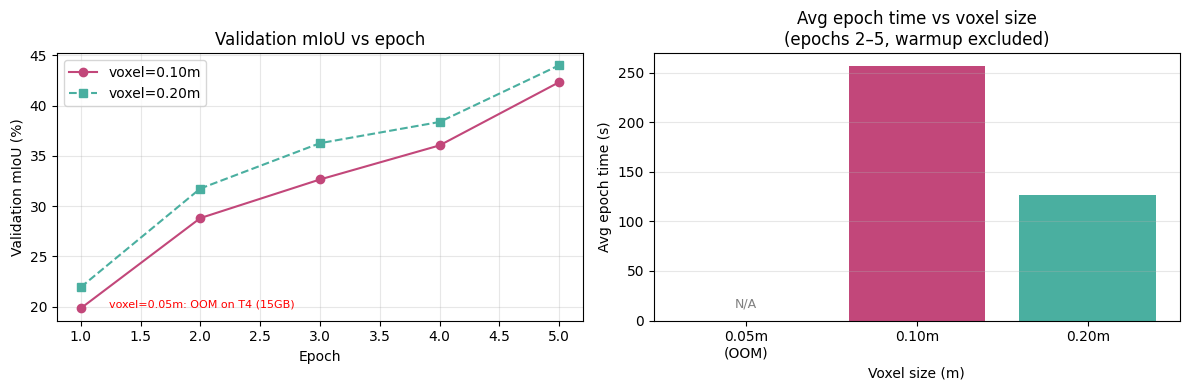

In [26]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, 6))

miou_010 = [19.83, 28.81, 32.65, 36.04, 42.33]
miou_020 = [21.93, 31.75, 36.26, 38.37, 44.01]

# avg epoch time (epochs 2-5 only, excluding warmup epoch 1)
avg_time_010 = np.mean([259.43, 257.21, 254.52, 256.75])
avg_time_020 = np.mean([126.66, 127.47, 127.12, 126.39])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# plot 1: val mIoU over epochs
axes[0].plot(epochs, miou_010, marker='o', label='voxel=0.10m', color='#C2477A')
axes[0].plot(epochs, miou_020, marker='s', linestyle='--', label='voxel=0.20m', color='#4AAFA0')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation mIoU (%)')
axes[0].set_title('Validation mIoU vs epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate('voxel=0.05m: OOM on T4 (15GB)',
                 xy=(0.10, 0.05), xycoords='axes fraction',
                 fontsize=8, color='red')

# plot 2: avg epoch time (excluding warmup)
labels  = ['0.05m\n(OOM)', '0.10m', '0.20m']
times   = [None, avg_time_010, avg_time_020]
colors  = ['#cccccc', '#C2477A', '#4AAFA0']
x = np.arange(len(labels))
bars = axes[1].bar(x, [0, avg_time_010, avg_time_020], color=colors)
bars[0].set_hatch('//')
axes[1].text(0, 10, 'N/A', ha='center', va='bottom', fontsize=9, color='gray')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Voxel size (m)')
axes[1].set_ylabel('Avg epoch time (s)')
axes[1].set_title('Avg epoch time vs voxel size\n(epochs 2–5, warmup excluded)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task41_voxel_study.png', dpi=150, bbox_inches='tight')
plt.show()

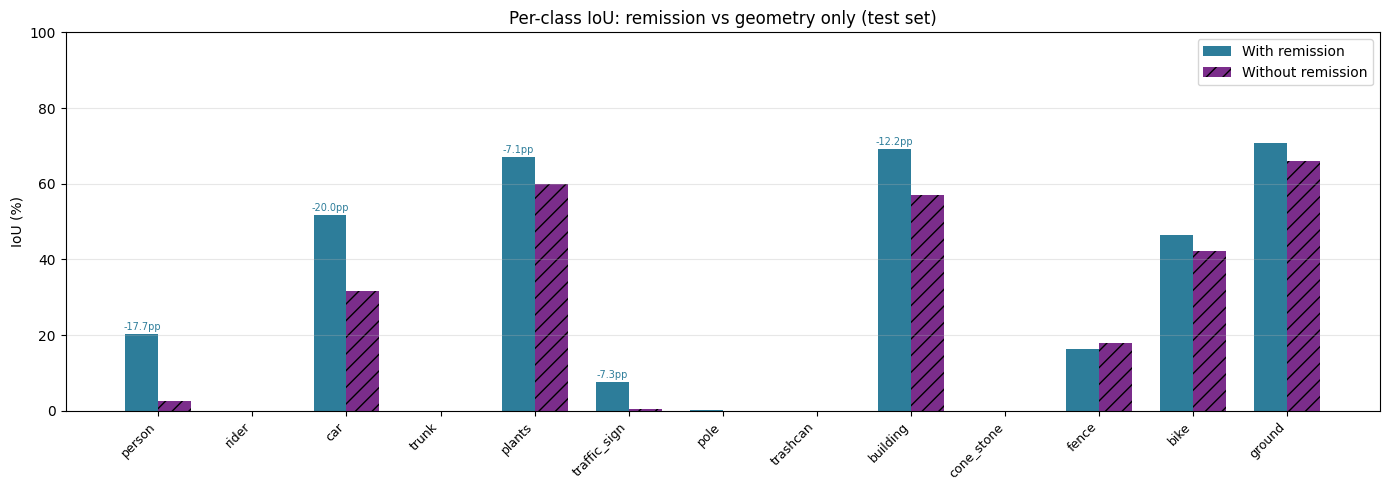

In [27]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_NAMES = [
    'person', 'rider', 'car', 'trunk', 'plants',
    'traffic_sign', 'pole', 'trashcan', 'building',
    'cone_stone', 'fence', 'bike', 'ground'
]

iou_with    = [20.26, 0.00, 51.67, 0.00, 67.03,
                7.69,  0.33, 0.00, 69.28, 0.00,
               16.34, 46.33, 70.73]

iou_without = [2.52,  0.00, 31.65, 0.00, 59.89,
               0.36,  0.00, 0.00, 57.10, 0.00,
               17.89, 42.26, 66.02]

x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_a = ax.bar(x - width/2, iou_with,    width,
                label='With remission',    color='#2D7D9A')
bars_b = ax.bar(x + width/2, iou_without, width,
                label='Without remission', color='#7B2D8B', hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('IoU (%)')
ax.set_ylim(0, 100)
ax.set_title('Per-class IoU: remission vs geometry only (test set)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# annotate largest drops
drops = [(i, iou_with[i] - iou_without[i]) for i in range(len(CLASS_NAMES))]
for i, drop in drops:
    if drop > 5:
        ax.annotate(f'-{drop:.1f}pp',
                    xy=(i - width/2, iou_with[i] + 1),
                    fontsize=7, ha='center', color='#2D7D9A')

plt.tight_layout()
plt.savefig('task42_remission_study.png', dpi=150, bbox_inches='tight')
plt.show()